# ML Heart Attack Prediction Model

The goal of this proyect is to predict the probabilities that a person will have a Heart Attack.
With this proyect we pretend to inform the people with Heart Disease Risk, the level of danger in which
they are in so they can get conscious if which to contact a Cardiologist. Furthermore, in extreme cases of
a colapsed sanitary system, it could help to stablish the people that should be treated with priority.

In [1]:
# Import all the necessary libraries for the project
# For data import and treatment
import pandas as pd
import numpy as np
# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries from Scikit-Learn
# For splitting the data into Train and Test Datasets, and choose the best ML model
from sklearn.model_selection import train_test_split, GridSearchCV
# To create pipelines
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
# To combine numerical and categorical columns in our case
from sklearn.compose import ColumnTransformer
# Import ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import get_scorer_names, accuracy_score, f1_score, recall_score, roc_auc_score

# Save the best model obtained 
import joblib

# Uses Streamlit to create an app for displaying the data
import streamlit as st

In [2]:
# Column names of the data set that we need to insert as the dataframe comes only with the values.
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

# Uploading to the script the data set and assigning the column na
df = pd.read_csv("/Users/oscarjoverarrate/Desktop/heart_attack_model/heart+disease/processed.cleveland.data",
                 names=column_names, na_values = '?')

# Gives an overview of the first 5 rows
print('\nFirst 5 rows of the Data Frame: ')
print(df.head())

# Gives the information of the data frame, columns, values, counts, and type of data
print('\nInfo of the Data Frame: ')
print(df.info())

# Gives the unique values of the data frame
print('\nUnique values of the Data Frame: ')
print(df.nunique())

# Indicates if there are missing values expressed as '?'
print('\nGives number of the charachter ? found in each column: ')
print((df == '?').sum())

# Indicates the NaN values that are in each column
print('\nGives number of Nan values found in each column: ')
print(df.isna().sum())

# Let's drop the data that has the NaN values
print('\nTaking out the rows with NaN values...')
df_nonan = df.dropna()

# Indicates the NaN values that are in each column
print('\nGives number of Nan values found in each column of the Data Frame with no NaN values: ')
print(df_nonan.isna().sum())


First 5 rows of the Data Frame: 
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Info of the Data Frame: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float

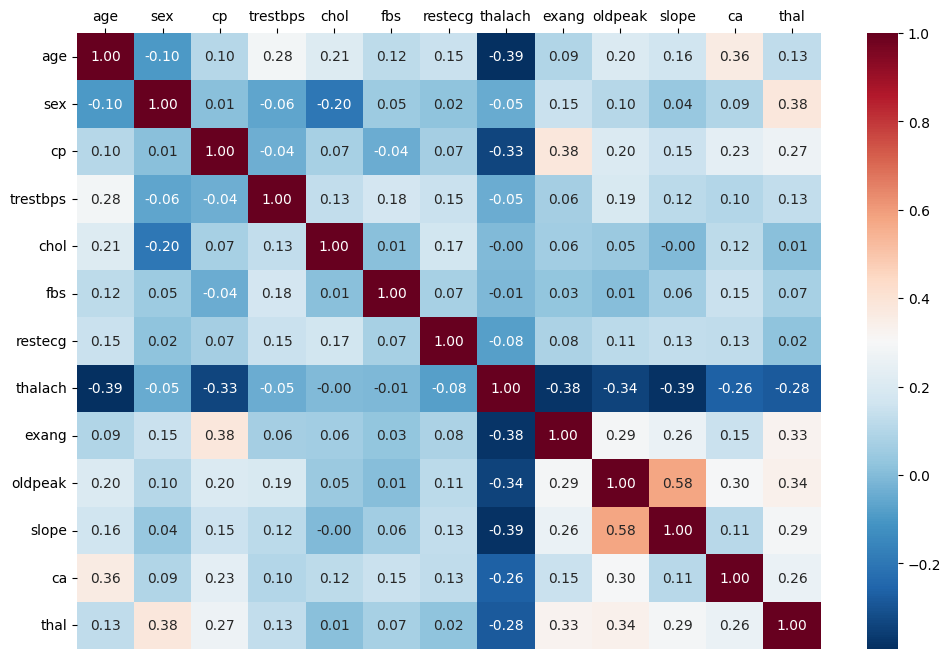

In [18]:
# We define X as the features dataframe and y as the target column
X = df.drop(columns = ['target'])
y = df['target']

# Turn the y column into binary values, we are only interested into if they had a heart attack or not
y = y.apply(lambda x: 1 if x > 0 else 0)

# We stablish a correlation Matrix
corr_matrix = X.corr(method = 'pearson')

# Plots a heat map with the correlations between each feature
fig, ax = plt.subplots(figsize = (12,8))
ax = sns.heatmap(corr_matrix, annot = True, cmap = 'RdBu_r',fmt=".2f")
ax.xaxis.tick_top()
plt.show()
plt.close()

# We split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y, 
                                                    test_size = .2, 
                                                    random_state=42,
                                                    stratify = y
                                                   )

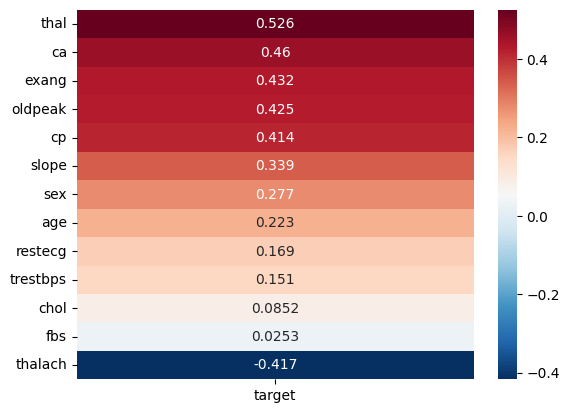

In [4]:
# We correlate the features with the target
X_y = X.copy()
X_y['target'] = y

# Does the correlation matrix of the X_y Data Frame
corr_matrix = X_y.corr()

# Isolate the column corresponding to the 'target'
corr_target = corr_matrix[['target']].drop(labels=['target'])

# Sorts the values of the corr_target matrix in an ascendent order
corr_target_sorted = corr_target.sort_values(by = 'target', ascending = False)

# Plots the graph
fig, ax = plt.subplots()
ax = sns.heatmap(corr_target_sorted, annot = True, cmap = 'RdBu_r', fmt = '0.3')
plt.show()
plt.close()

In [5]:
# Although here all the columns are numerical as inicated in the df.info() display, as an exercise let's separate
# the numerical columns from the categorical ones

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns


In [6]:
# Creating the numerical pipeline

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy = 'median')),
                          ('scaler', StandardScaler())])

In [7]:
# Creating the categorical pipeline

cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy = 'most_frequent')),
                        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))])

In [8]:
# Combines both numerical and categorical columns

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [9]:
# It puts the preprocessor in a pipeline to put it later in a GridSearchCV

pipeline = Pipeline([('preprocess', preprocessor),
                    ('clf', LogisticRegression(random_state=42))])

In [10]:
# In order to select between different models we are going to create a search_space variable that involves
# different clasification ML models as the purpose of the project is to classify between the people that
# could have a heart attack and its probability of having it

search_space = [
    {
     'clf': [LogisticRegression(random_state=42)], 
     'clf__C':np.logspace(-3,3,7)
    },
    {
     'clf': [RandomForestClassifier(random_state=42)],
     'clf__n_estimators': [100, 300],
     'clf__max_depth': [None, 5, 10]
    },
    {
     'clf': [GradientBoostingClassifier(random_state=42)],
     'clf__n_estimators': [100, 200],
     'clf__learning_rate': [0.01, 0.1]
    }]

## Best Model Selected

The selection of the best model is based by ROC-AUC, as such metric is extremely relevant in medical cases. However, below, select the best model by recall, f1 score and accuracy respectively.
With the four metrics depicted in all of them for a further comparison.

In [11]:
# It searches for the best model basing it in the ROC-AUC score
gs = GridSearchCV(estimator=pipeline, param_grid=search_space, scoring='roc_auc', cv=5)

# Trains de model
gs.fit(X_train, y_train)

# Prints best model
#print('Best Model:')
best_model = gs.best_estimator_
#print(gs.best_estimator_)

# Best attributes of our clasification model
print('The best model based on ROC-AUC was: ', best_model.named_steps['clf'])

# Best scores of the best model

# Values predicted by best model
y_pred = best_model.predict(X_test)

# Shows accuracy score
print('Accuracy: ', accuracy_score(y_test, y_pred))

# Shows f1 score
print('F1 Score: ', f1_score(y_test, y_pred))

# Shows recall score
print('Recall: ', recall_score(y_test, y_pred))

# Shows roc-auc score
print('ROC-AUC: ', roc_auc_score(y_test, y_pred))

The best model based on ROC-AUC was:  RandomForestClassifier(max_depth=5, n_estimators=300, random_state=42)
Accuracy:  0.9016393442622951
F1 Score:  0.896551724137931
Recall:  0.9285714285714286
ROC-AUC:  0.9036796536796536


## Saving the best model based on AUC-ROC score 

In [12]:
# The final selected model was safed for potential deployment
print('The final selected model was safed for potential deployment')
joblib.dump(gs.best_estimator_, 'ML_Heart_Attack_Best_Model.pkl')

The final selected model was safed for potential deployment


['ML_Heart_Attack_Best_Model.pkl']

## Model selection based on recall, F1 score and accuracy respectively

In [13]:
# It searches for the best model basing it in the recall score
gs = GridSearchCV(estimator=pipeline, param_grid=search_space, scoring='recall', cv=5)

# Trains de model
gs.fit(X_train, y_train)

# Prints best model
#print('Best Model:')
best_model = gs.best_estimator_
#print(gs.best_estimator_)

# Best attributes of our clasification model
print('The best model based on recall was: ', best_model.named_steps['clf'])

# Best scores of the best model

# Values predicted by best model
y_pred = best_model.predict(X_test)

# Shows accuracy score
print('Accuracy: ', accuracy_score(y_test, y_pred))

# Shows f1 score
print('F1 Score: ', f1_score(y_test, y_pred))

# Shows recall score
print('Recall: ', recall_score(y_test, y_pred))

# Shows roc-auc score
print('ROC-AUC: ', roc_auc_score(y_test, y_pred))

The best model based on recall was:  LogisticRegression(C=10.0, random_state=42)
Accuracy:  0.8688524590163934
F1 Score:  0.8666666666666667
Recall:  0.9285714285714286
ROC-AUC:  0.8733766233766233


In [14]:
# It searches for the best model basing it in the f1 score
gs = GridSearchCV(estimator=pipeline, param_grid=search_space, scoring='f1', cv=5)

# Trains de model
gs.fit(X_train, y_train)

# Prints best model
#print('Best Model:')
best_model = gs.best_estimator_
#print(gs.best_estimator_)

# Best attributes of our clasification model
print('The best model based on F1 score was: ', best_model.named_steps['clf'])

# Best scores of the best model

# Values predicted by best model
y_pred = best_model.predict(X_test)

# Shows accuracy score
print('Accuracy: ', accuracy_score(y_test, y_pred))

# Shows f1 score
print('F1 Score: ', f1_score(y_test, y_pred))

# Shows recall score
print('Recall: ', recall_score(y_test, y_pred))

# Shows roc-auc score
print('ROC-AUC: ', roc_auc_score(y_test, y_pred))

The best model based on F1 score was:  LogisticRegression(C=0.1, random_state=42)
Accuracy:  0.8524590163934426
F1 Score:  0.847457627118644
Recall:  0.8928571428571429
ROC-AUC:  0.8555194805194805


In [15]:
# It searches for the best model basing it in the accuracy score
gs = GridSearchCV(estimator=pipeline, param_grid=search_space, scoring='accuracy', cv=5)

# Trains de model
gs.fit(X_train, y_train)

# Prints best model
#print('Best Model:')
best_model = gs.best_estimator_
#print(gs.best_estimator_)

# Best attributes of our clasification model
print('Best attributes of our classification model')
print(best_model.named_steps['clf'])

# Best attributes of our clasification model
print('The best model based on accuracy was: ', best_model.named_steps['clf'])

# Best scores of the best model

# Values predicted by best model
y_pred = best_model.predict(X_test)

# Shows accuracy score
print('Accuracy: ', accuracy_score(y_test, y_pred))

# Shows f1 score
print('F1 Score: ', f1_score(y_test, y_pred))

# Shows recall score
print('Recall: ', recall_score(y_test, y_pred))

# Shows roc-auc score
print('ROC-AUC: ', roc_auc_score(y_test, y_pred))

Best attributes of our classification model
LogisticRegression(C=0.1, random_state=42)
The best model based on accuracy was:  LogisticRegression(C=0.1, random_state=42)
Accuracy:  0.8524590163934426
F1 Score:  0.847457627118644
Recall:  0.8928571428571429
ROC-AUC:  0.8555194805194805
